# 03 — xarray on Zarr: labeled cubes
How you actually consume Zarr: labeled dims, lazy open, label-based cutouts.

In [1]:
import xarray as xr, numpy as np, pandas as pd
ds = xr.Dataset(
    {"flux": (("time", "y", "x"),
              np.random.default_rng(2).normal(size=(30, 1024, 1024)).astype("float32"))},
    coords={"time": pd.date_range("2026-01-01", periods=30, freq="D"),
            "y": np.arange(1024), "x": np.arange(1024)})
ds.flux.attrs["units"] = "MJy/sr"
ds.to_zarr("../data/labeled.zarr", mode="w",
           encoding={"flux": {"chunks": (5, 256, 256)}})
print("written")

written


/Users/ejoliet/devspace/ejoliet/zarr-course/.venv/lib/python3.13/site-packages/zarr/api/asynchronous.py:246: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## Lazy open — milliseconds at any scale (metadata/data separation)

In [2]:
import time
t0 = time.perf_counter(); ds2 = xr.open_zarr("../data/labeled.zarr")
print(f"open_zarr: {(time.perf_counter()-t0)*1000:.1f} ms"); ds2

open_zarr: 77.0 ms


<xarray.Dataset> Size: 126MB
Dimensions:  (time: 30, y: 1024, x: 1024)
Coordinates:
  * time     (time) datetime64[ns] 240B 2026-01-01 2026-01-02 ... 2026-01-30
  * y        (y) int64 8kB 0 1 2 3 4 5 6 ... 1017 1018 1019 1020 1021 1022 1023
  * x        (x) int64 8kB 0 1 2 3 4 5 6 ... 1017 1018 1019 1020 1021 1022 1023
Data variables:
    flux     (time, y, x) float32 126MB dask.array<chunksize=(5, 256, 256), meta=np.ndarray>

## Label-based cutout = server-free SODA primitive
Slicing by label pulls only intersecting chunks.

In [3]:
cut = ds2.flux.sel(time="2026-01-15", y=slice(100, 400), x=slice(100, 400))
float(cut.mean().compute())

0.0038788006640970707

## Append along time — the daily-pipeline pattern

In [4]:
ds_new = xr.Dataset(
    {"flux": (("time", "y", "x"), np.ones((5, 1024, 1024), "float32"))},
    coords={"time": pd.date_range("2026-01-31", periods=5, freq="D"),
            "y": np.arange(1024), "x": np.arange(1024)})
ds_new.to_zarr("../data/labeled.zarr", append_dim="time")
print("time length now:", xr.open_zarr("../data/labeled.zarr").sizes["time"])

time length now: 35


/Users/ejoliet/devspace/ejoliet/zarr-course/.venv/lib/python3.13/site-packages/zarr/api/asynchronous.py:246: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Unable to revert mtime: /Library/Fonts
Matplotlib is building the font cache; this may take a moment.


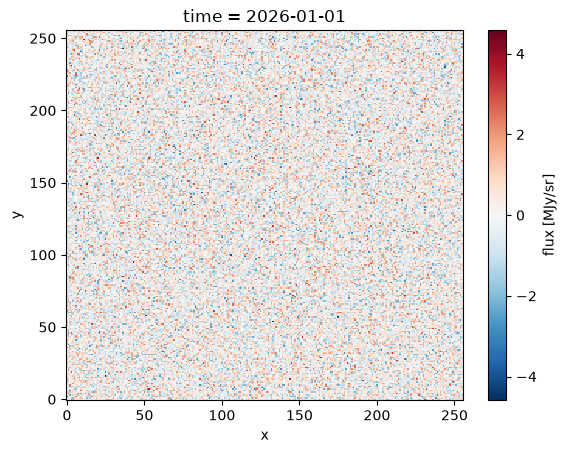

In [5]:
# hygiene: quick visual
import matplotlib.pyplot as plt
ds2.flux.isel(time=0, y=slice(0, 256), x=slice(0, 256)).plot(); plt.show()